In [1]:
!cp /kaggle/input/models/ygozynju/preprocessing-lib/other/default/1/Preprocessing_lib.py /kaggle/working/
!cp /kaggle/input/models/ygozynju/backtest-lib/other/default/1/Backtest_lib.py /kaggle/working/

In [2]:
import numpy as np
import pandas as pd
import cvxpy as cp
import scipy
import tqdm
import gc


from numba import njit
from scipy import stats,optimize
from scipy.stats import spearmanr
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import RidgeClassifier,Ridge
from sklearn.covariance import LedoitWolf

from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import torch

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from Preprocessing_lib import compute_sectional_zscores,compute_factor_signals
from Backtest_lib import metrics_report

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Load Data and Feature Engineering

In [4]:
@njit
def _numba_sar_calc(high: np.ndarray, low: np.ndarray, close: np.ndarray, 
                    af_start: float = 0.02, af_step: float = 0.02, af_max: float = 0.2) -> np.ndarray:
    """Ultra-fast Parabolic SAR calculation compiled on the fly using Numba."""
    n = len(close)
    sar = np.zeros(n)
    if n < 2:
        return sar
        
    is_long = close[1] > close[0]
    sar[1] = low[0] if is_long else high[0]
    af = af_start
    ep = high[1] if is_long else low[1]
    
    for t in range(2, n):
        sar[t] = sar[t-1] + af * (ep - sar[t-1])
        if is_long:
            sar[t] = min(sar[t], low[t-1], low[t-2])
            if low[t] < sar[t]:
                is_long = False
                sar[t] = ep
                ep = low[t]
                af = af_start
            elif high[t] > ep:
                ep = high[t]
                af = min(af + af_step, af_max)
        else:
            sar[t] = max(sar[t], high[t-1], high[t-2])
            if high[t] > sar[t]:
                is_long = True
                sar[t] = ep
                ep = high[t]
                af = af_start
            elif low[t] < ep:
                ep = low[t]
                af = min(af + af_step, af_max)
    return sar

def build_technical_features(df: pd.DataFrame, zscore: bool = False) -> pd.DataFrame:
    """Compute technical indicators from OHLCV + returns panel data."""
    eps = 10**(-9)
    
    df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
    dg = df[['Date', 'returns']].copy()
    g = df.groupby('Ticker')
    
    # ────────────────────────────────── Trend ──────────────────────────────────────────
    for w in [5, 12, 26, 63]:
        dg[f'ema_{w}'] = g['returns'].transform(lambda x: x.ewm(span=w, adjust=False).mean())
        df[f'returns_vs_ema_{w}'] = (df['returns'] - dg[f'ema_{w}']) / (dg[f'ema_{w}'] + eps)

    df['macd'] = dg['ema_12'] - dg['ema_26']
    
    g = df.groupby('Ticker')
    df['macd_signal'] = g['macd'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
    df['macd_hist']   = df['macd'] - df['macd_signal']
  
    # --- PARABOLIC SAR VIA NUMBA ---
    def _apply_sar(grp):
        grp['sar'] = _numba_sar_calc(grp['High'].values, grp['Low'].values, grp['Close'].values)
        grp['sar_distance'] = (grp['Close'] - grp['sar']) / (grp['Close'] + eps)
        return grp

    df = df.groupby('Ticker', group_keys=False).apply(_apply_sar)
    g = df.groupby('Ticker') 
    
    # ────────────────────────── Momentum ─────────────────────────────────────────────
    def _rsi(s, p=14):
        d = s.diff()
        g_val = d.clip(lower=0).ewm(alpha=1/p, adjust=False).mean()
        l_val = (-d.clip(upper=0)).ewm(alpha=1/p, adjust=False).mean()
        return 100 - 100 / (1 + g_val / l_val.replace(0, np.nan))

    df['rsi_14'] = g['Close'].transform(_rsi)
    df['rsi_7']  = g['Close'].transform(lambda x: _rsi(x, 7))

    def _stoch(grp, k=14):
        lo, hi = grp['Low'].rolling(k).min(), grp['High'].rolling(k).max()
        return 100 * (grp['Close'] - lo) / (hi - lo).replace(0, np.nan)

    df['stoch_k'] = df.groupby('Ticker', group_keys=False).apply(_stoch)
    df['stoch_d'] = g['stoch_k'].transform(lambda x: x.rolling(3).mean())

    def _williams_r(grp, w=14):
        hi, lo = grp['High'].rolling(w).max(), grp['Low'].rolling(w).min()
        return -100 * (hi - grp['Close']) / (hi - lo).replace(0, np.nan)

    df['williams_r'] = df.groupby('Ticker', group_keys=False).apply(_williams_r)

    for w in [5, 21, 63, 126, 252]:
        df[f"mom_{w}"] = df.groupby("Ticker")["Close"].pct_change(w)
    
    # ───────────────────────────── Volatility ────────────────────────────────────────────────
    sma20 = g['returns'].transform(lambda x: x.rolling(20).mean())
    std20 = g['returns'].transform(lambda x: x.rolling(20).std())
    df['bb_upper'] = sma20 + 2 * std20
    df['bb_lower'] = sma20 - 2 * std20
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / (sma20 + eps)
    df['bb_pct']   = (df['returns'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'] + eps)

    def _atr(grp, w=14):
        tr = pd.concat([
            grp['High'] - grp['Low'],
            (grp['High'] - grp['Close'].shift()).abs(),
            (grp['Low']  - grp['Close'].shift()).abs(),
        ], axis=1).max(axis=1)
        return tr.ewm(span=w, adjust=False).mean()

    df['atr_14']  = df.groupby('Ticker', group_keys=False).apply(_atr)
    df['atr_pct'] = df['atr_14'] / df['Close']

    for w in [10, 21, 63]:
        df[f'hvol_{w}'] = g['returns'].transform(lambda x: x.rolling(w).std() * np.sqrt(252))

    df['vol_ratio'] = df['hvol_10'] / (df['hvol_63'] + eps)
    ema20_c         = g['Close'].transform(lambda x: x.ewm(span=20).mean())
    df['kc_upper']  = ema20_c + 2 * df['atr_14']
    df['kc_lower']  = ema20_c - 2 * df['atr_14']

    # ─────────────────────────────── Volume ──────────────────────────────────────────────────────
    def _obv(grp):
        return (np.sign(grp['Close'].diff()).fillna(0) * grp['Volume']).cumsum()

    df['obv'] = df.groupby('Ticker', group_keys=False).apply(_obv)

    def _vwap(grp, w=20):
        tp = (grp['High'] + grp['Low'] + grp['Close']) / 3
        return (tp * grp['Volume']).rolling(w).sum() / grp['Volume'].rolling(w).sum()

    df['vwap_20']       = df.groupby('Ticker', group_keys=False).apply(_vwap)
    df['close_vs_vwap'] = (df['Close'] - df['vwap_20']) / df['vwap_20']

    def _cmf(grp, w=20):
        hl  = (grp['High'] - grp['Low']).replace(0, np.nan)
        mfv = ((grp['Close'] - grp['Low']) - (grp['High'] - grp['Close'])) / hl * grp['Volume']
        return mfv.rolling(w).sum() / grp['Volume'].rolling(w).sum()

    df['cmf_20'] = df.groupby('Ticker', group_keys=False).apply(_cmf)

    def _mfi(grp, w=14):
        # Money Flow Index
        tp  = (grp['High'] + grp['Low'] + grp['Close']) / 3
        mf  = tp * grp['Volume']
        pos = mf.where(tp > tp.shift(), 0).rolling(w).sum()
        neg = mf.where(tp < tp.shift(), 0).rolling(w).sum()
        return 100 - 100 / (1 + pos / neg.replace(0, np.nan))

    df['mfi_14']        =  df.groupby('Ticker', group_keys=False).apply(_mfi)
    vol_ma              =  g['Volume'].transform(lambda x: x.rolling(20).mean())
    df['volume_surge']  =  df['Volume'] / vol_ma

    # ──────────────────────────────── Structure ──────────────────────────────────────────────
    df['sharpe_20d']    =  sma20 / (std20 + eps)
    df['sharpe_5d']     =  df['returns_vs_ema_5']/ (df['hvol_10'] + eps)
    df['high_52w']      =  g['High'].transform(lambda x: x.rolling(252).max())
    df['low_52w']       =  g['Low'].transform(lambda x: x.rolling(252).min())
    df['pct_from_high'] =  (df['Close'] - df['high_52w']) / df['high_52w']
    df['pct_from_low']  =  (df['Close'] - df['low_52w'])  / df['low_52w']
    df['gap']           =  g['Open'].transform(lambda x: (x - x.shift()) / x.shift())
    df['body_size']     =  (df['Close'] - df['Open']).abs() / df['Open']
    df['upper_wick']    =  (df['High'] - df[['Open', 'Close']].max(axis=1)) / df['Open']
    df['lower_wick']    =  (df[['Open', 'Close']].min(axis=1) - df['Low']) / df['Open']
    df['bullish_bar']   =  (df['Close'] - df['Open']) / df['Open']
    df["hl_spread"]     =  (df["High"] - df["Low"]) / (df["Close"] + eps)

    # ──────────────────────────────── Market ──────────────────────────────────────────────
    market_dates = df.drop_duplicates("Date").sort_values("Date")

    for w in [21, 63, 252]:
        rolling_vol  = market_dates["benchmark"].rolling(window=w).std() 
        rolling_mean = market_dates["benchmark"].rolling(window=w).mean()

        vol_mapping  = dict(zip(market_dates["Date"], rolling_vol))
        mean_mapping = dict(zip(market_dates["Date"], rolling_mean))

        df[f"market_vol_{w}"] = df["Date"].map(vol_mapping)
        df[f"market_mom_{w}"] = df['benchmark'] - df["Date"].map(mean_mapping)
        df[f"market_sharpe_{w}"] = df[f"market_mom_{w}"] / (df[f"market_vol_{w}"] + eps)

    return df

In [5]:
fundamental_cols = [ 
                    'asset_turnover','debt_ratio',
                    'roic_proxy','earnings_yield','roa',
                    'roe','book_to_price','sales_to_price',
                    'hvol_10','hvol_21','hvol_63','mom_5','vol_ratio',
                    'mom_21', 'mom_63', 'mom_126','mom_252',
                    'returns','Volume','sharpe_20d','sharpe_5d',
    
       
                    'TotalAssets','TotalLiabilities', 'Equity', 'Cash', 
                    'LongTermDebt', 'Revenue','DividendsPaid','NetIncome', 
                    'OperatingIncome', 'OperatingCF', 'CapEx','GrossProfit',
                    'RnD', 'EPS_Basic', 'EPS_Diluted', 'MarketCap',
                    'Assets_Growth_3m', 'Assets_Growth_6m', 'Assets_Growth_12m',
                    'Equity_Growth_3m', 'Equity_Growth_6m', 'Equity_Growth_12m',
                    'LongTermDebt_Growth_3m', 'LongTermDebt_Growth_6m',
                    'LongTermDebt_Growth_12m', 'Revenue_Growth_3m', 'Revenue_Growth_6m',
                    'Revenue_Growth_12m', 'NetIncome_Growth_3m', 'NetIncome_Growth_6m',
                    'NetIncome_Growth_12m', 'OperatingIncome_Growth_3m',
                    'OperatingIncome_Growth_6m', 'OperatingIncome_Growth_12m',
                    'OperatingCF_Growth_3m', 'OperatingCF_Growth_6m',
                    'OperatingCF_Growth_12m', 'RnD_Growth_3m', 'RnD_Growth_6m',
                    'RnD_Growth_12m',
                  ]

drop_cols = [
                'Date', 'Ticker','PeriodEnd','industry', 'shortName', 'filed', # Date and categorical features
                'target','returns',
                'Open', 'High', 'Low', 'Close', 
    
                'Revenue_alt','DividendsPaid','GrossProfit', 'RnD',
                'SharesOutstanding','MarketCap','CapEx',
                'OperatingIncome','OperatingCF','NetIncome',
                'TotalLiabilities','TotalAssets',  'asset_turnover',
                'Cash','Revenue', 'LongTermDebt','EPS_Diluted','EPS_Basic',
                'net_margin','operating_margin',
    
                'OperatingCF_Growth_12m','Revenue_Growth_12m','Equity_Growth_12m', 
                'LongTermDebt_Growth_12m', 'OperatingIncome_Growth_12m','NetIncome_Growth_12m',
                'RnD_Growth_12m','Assets_Growth_12m',
    
                'NetIncome_Growth_6m','OperatingCF_Growth_6m',
                'LongTermDebt_Growth_6m','Equity_Growth_6m', 'Assets_Growth_6m', 
                'Revenue_Growth_6m','OperatingIncome_Growth_6m', 

                'Equity_Growth_3m','RnD_Growth_3m','OperatingIncome_Growth_3m',
                'Revenue_Growth_3m','NetIncome_Growth_3m', 'OperatingCF_Growth_3m'
            ]

In [6]:
path         =  '/kaggle/input/datasets/ygozynju/dataset-s-and-p-500-daily/df_total_edgar.parquet'
df           =  pd.read_parquet(path)
df['Date']   =  pd.to_datetime(df['Date'])
df['sector'] =  df['sector'].fillna('other')
df

,Date,Open,High,Low,Close,Volume,returns,shortName,sector,industry,...,OperatingIncome_Growth_12m,OperatingCF_Growth_3m,OperatingCF_Growth_6m,OperatingCF_Growth_12m,RnD_Growth_3m,RnD_Growth_6m,RnD_Growth_12m,MarketCap,Ticker,GrossProfit
0,2007-01-03,22.146527,22.456666,21.551564,21.709799,3599291.0,-0.015782,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN
1,2007-01-04,21.709798,21.899679,21.178130,21.779421,2899033.0,0.003207,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN
2,2007-01-05,21.709799,21.773093,21.519918,21.576881,3741887.0,-0.009300,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN
3,2007-01-08,21.507262,21.570554,21.317379,21.500933,2176966.0,-0.003520,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN
4,2007-01-09,21.570551,21.722457,21.285729,21.526247,1937908.0,0.001177,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2247863,2026-03-24,113.889999,117.110001,113.300003,115.930000,4561800.0,0.006075,Zoetis Inc.,Healthcare,Drug Manufacturers - Specialty & Generic,...,NaN,0.0,0.0,-0.013445,NaN,NaN,NaN,4.926185e+10,ZTS,NaN
2247864,2026-03-25,117.260002,118.139999,115.300003,116.709999,3078900.0,0.006728,Zoetis Inc.,Healthcare,Drug Manufacturers - Specialty & Generic,...,NaN,0.0,0.0,-0.013445,NaN,NaN,NaN,4.959329e+10,ZTS,NaN
2247865,2026-03-26,115.639999,118.580002,115.300003,116.629997,2725900.0,-0.000685,Zoetis Inc.,Healthcare,Drug Manufacturers - Specialty & Generic,...,NaN,0.0,0.0,-0.013445,NaN,NaN,NaN,4.955930e+10,ZTS,NaN
2247866,2026-03-27,116.809998,117.290001,113.290001,113.349998,3601800.0,-0.028123,Zoetis Inc.,Healthcare,Drug Manufacturers - Specialty & Generic,...,NaN,0.0,0.0,-0.013445,NaN,NaN,NaN,4.816554e+10,ZTS,NaN


In [7]:
df = compute_factor_signals(df)
features_df  = build_technical_features(df)
compute_sectional_zscores(features_df, fundamental_cols)

0

In [8]:
horizon = 1
target_name = "returns_zscore"
features_df["target"] = features_df.groupby("Ticker")[target_name].shift(-horizon)
features_df = features_df.dropna(subset=['returns','target'])
features_df = features_df.sort_values(by=['Date','Ticker'])

In [9]:
# -----------------------------
# Feature sets
# -----------------------------
end_date = '2015-01-01'
train = features_df.copy()
train = train[train['Date'] < end_date]

cat_cols_tree = ["sector"]
train[cat_cols_tree] = train[cat_cols_tree].astype('category')
feature_cols = [c for c in train.columns if c not in drop_cols]
num_cols_linear = [c for c in feature_cols if c not in cat_cols_tree]

cat_feature_indices = [feature_cols.index(c) for c in cat_cols_tree]

# -----------------------------
# IC Evaluation Function
# -----------------------------
def compute_ic(df, pred_series, target_col="target", date_col="Date"):
    """
        Computes Mean Cross-Sectional Rank Information Coefficient (IC)
    """
    tmp = df[[date_col, target_col]].copy()
    tmp["pred"] = pred_series
    
    # Calculate Spearman correlation per date group
    ics = tmp.groupby(date_col).apply(
        lambda g: spearmanr(g["pred"], g[target_col])[0] if len(g) > 1 else np.nan
    )
    return ics.mean()

# -----------------------------
# Model configs
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler())
        ]), num_cols_linear),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe",     OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_tree),
    ],
    remainder="drop"
)

ridge_model = Pipeline([
    ("prep", preprocessor),
    ("clf",  Ridge(alpha=2.0))
])

lgb_params = dict(
    objective="regression",     # Changed to regression
    metric="rmse",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

cat_params = dict(
    loss_function="RMSE",       # Changed to regression metric
    eval_metric="RMSE",
    iterations=2000,
    learning_rate=0.01,
    depth=6,
    l2_leaf_reg=5.0,
    bagging_temperature=0.65,
    min_data_in_leaf=80,
    random_strength=0.8,
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    task_type = "GPU"
)

# -----------------------------
# CV
# -----------------------------
cv     = 3
dates  = train["Date"].values
y      = train["target"].values  # Keeping raw returns for regression
gkf    = TimeSeriesSplit(n_splits=cv)

oof_lgb   = np.zeros(len(train))
oof_cat   = np.zeros(len(train))
oof_ridge = np.zeros(len(train))
feature_importances = pd.Series(np.zeros(len(feature_cols)),index = feature_cols,name='importance')

# Creating an evaluated index tracker to compute overall OOF IC over predicted dates
evaluated_indices = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(dates), 1):
    print(f"\n{'='*50}\nFold {fold}\n{'='*50}")
    evaluated_indices.extend(va_idx)

    X_tr = train.iloc[tr_idx][feature_cols]
    X_va = train.iloc[va_idx][feature_cols]
    y_tr = y[tr_idx]
    y_va = y[va_idx]
    df_va = train.iloc[va_idx]

    # ------ 1. LightGBM ------
    lgb_model = lgb.LGBMRegressor(**lgb_params, force_col_wise=True) # Regressor
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        categorical_feature=cat_cols_tree,
        callbacks=[
            lgb.early_stopping(stopping_rounds=200, verbose=False),
            lgb.log_evaluation(period=0),
        ]
    )
    oof_lgb[va_idx] = lgb_model.predict(X_va)
    feature_importances += lgb_model.feature_importances_

    # ------ 2. CatBoost ------
    cat_model = CatBoostRegressor(**cat_params) # Regressor
    cat_model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        cat_features=cat_feature_indices,
        verbose=False,
    )
    oof_cat[va_idx] = cat_model.predict(X_va)
    
    # ------ 3. Ridge ------
    ridge_model.fit(X_tr, y_tr)
    oof_ridge[va_idx] = ridge_model.predict(X_va) # Raw numeric projections

    # ------ Fold Rank IC Metrics ------
    fold_ic_lgb   = compute_ic(df_va, oof_lgb[va_idx])
    fold_ic_cat   = compute_ic(df_va, oof_cat[va_idx])
    fold_ic_ridge = compute_ic(df_va, oof_ridge[va_idx])
    
    print(f"  LGB   Rank IC : {fold_ic_lgb:.5f}  (best iter: {lgb_model.best_iteration_})")
    print(f"  Cat   Rank IC : {fold_ic_cat:.5f}  (best iter: {cat_model.best_iteration_})")
    print(f"  Ridge Rank IC : {fold_ic_ridge:.5f}")

# -----------------------------
# OOF scores
# -----------------------------
eval_train_df = train.iloc[evaluated_indices]

print("\n" + "="*50)
print("OOF Summary - Mean Cross-Sectional Rank IC:")
print("OOF LGB   Rank IC :", compute_ic(eval_train_df, oof_lgb[evaluated_indices]))
print("OOF Cat   Rank IC :", compute_ic(eval_train_df, oof_cat[evaluated_indices]))
print("OOF Ridge Rank IC :", compute_ic(eval_train_df, oof_ridge[evaluated_indices]))


Fold 1
  LGB   Rank IC : 0.03025  (best iter: 43)
  Cat   Rank IC : 0.03314  (best iter: 509)
  Ridge Rank IC : 0.02624

Fold 2
  LGB   Rank IC : 0.02442  (best iter: 113)
  Cat   Rank IC : 0.02609  (best iter: 1087)
  Ridge Rank IC : 0.01130

Fold 3
  LGB   Rank IC : 0.03017  (best iter: 85)
  Cat   Rank IC : 0.03562  (best iter: 1987)
  Ridge Rank IC : 0.02217

OOF Summary - Mean Cross-Sectional Rank IC:
OOF LGB   Rank IC : 0.02844145478551785
OOF Cat   Rank IC : 0.03179028703782939
OOF Ridge Rank IC : 0.02011474282453443


In [10]:
feature_importances.sort_values()

LongTermDebt_Growth_3m     13.0
accruals                   16.0
debt_ratio                 17.0
sales_to_price             19.0
eps_yield                  20.0
                          ...  
upper_wick                417.0
mom_252                   418.0
hvol_63                   431.0
lower_wick                438.0
returns_zscore            475.0
Name: importance, Length: 78, dtype: float64

In [11]:
feature_importances.sort_values()[-20:]

market_sharpe_63    289.0
close_vs_vwap       293.0
pct_from_low        294.0
hvol_10             320.0
mom_5               322.0
market_vol_63       323.0
market_sharpe_21    331.0
market_vol_21       334.0
pct_from_high       350.0
market_mom_21       351.0
market_vol_252      364.0
mom_63              370.0
hvol_21             376.0
volume_surge        380.0
mom_126             397.0
upper_wick          417.0
mom_252             418.0
hvol_63             431.0
lower_wick          438.0
returns_zscore      475.0
Name: importance, dtype: float64

In [9]:
feature_cols = [
    c
    for c in features_df.columns
    if c not in drop_cols
]

In [10]:
def train_lgbm(train_df, feature_cols, cat_cols_tree, train_size=0.9, task_type='CPU', algo='lgbm'):
    
    n_train = int(len(train_df) * train_size)
    X_train = train_df[feature_cols].iloc[:n_train]
    X_val   = train_df[feature_cols].iloc[n_train:]
    y_train = train_df["target"].iloc[:n_train]
    y_val   = train_df["target"].iloc[n_train:]
    
    cat_feature_indices = [feature_cols.index(c) for c in cat_cols_tree]

    if algo == 'lgbm':
        from lightgbm import LGBMRegressor
        import lightgbm as lgb
        model = LGBMRegressor(
            objective="regression", metric="rmse", n_estimators=2000,
            learning_rate=0.03, num_leaves=64, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=1.0, reg_lambda=2.0, random_state=42, n_jobs=-1, verbose=-1
        )
        model.fit(
            X_train, y_train, eval_set=[(X_val, y_val)],
            categorical_feature=cat_cols_tree,
            callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False), lgb.log_evaluation(period=0)]
        )
    elif algo == 'catboost':
        from catboost import CatBoostRegressor
        model = CatBoostRegressor(
            loss_function="RMSE", eval_metric="RMSE", iterations=2000,
            learning_rate=0.01, depth=6, l2_leaf_reg=5.0, bagging_temperature=0.65,
            min_data_in_leaf=80, random_strength=0.8, random_seed=42,
            task_type=task_type, verbose=False, allow_writing_files=False
        )
        model.fit(X_train, y_train, 
                  eval_set=(X_val, y_val), 
                  cat_features=cat_feature_indices
                 )

    return model

def generate_score(data, feature_cols, train_size=0.8, algo='lgbm', start_year=2017, end_year=2026):
    results = []
    
    data = data.copy()
    cat_cols_tree = data[feature_cols].select_dtypes(include=['object', 'category']).columns.to_list()
    for col in cat_cols_tree:
        data[col] = data[col].astype('category')
        
    years = sorted(data["Date"].dt.year.unique())
    task_type = "GPU" if torch.cuda.is_available() else "CPU"

    for year in tqdm.tqdm(years):
        if year < start_year or year > end_year:
            continue
        train_mask = data["Date"].dt.year < year
        test_mask  = data["Date"].dt.year == year
        
        if not train_mask.any() or not test_mask.any():
            continue
            
        train = data[train_mask]
        test  = data[test_mask].copy()
        
        model = train_lgbm(train, feature_cols, cat_cols_tree, train_size=train_size, task_type=task_type, algo=algo)
        test["score"] = model.predict(test[feature_cols])
        
        results.append(test)
        
        del train, test, model
        gc.collect() 

    return pd.concat(results, axis=0)

In [11]:
screen = generate_score(    features_df, feature_cols,
                            algo='lgbm',start_year=2017, end_year=2025
                        )

rank_ic = (
            screen.groupby("Date")
                .apply(
                    lambda x:
                    spearmanr(
                        x["score"],
                        x["target"]
                    )[0]
                )
        )

print(
    "Rank IC:",
    rank_ic.mean()
)

100%|██████████| 20/20 [07:32<00:00, 22.60s/it]


Rank IC: 0.01881750601956024


In [71]:
def optim_slsqp(mu,sigma,allow_short):
    n = len(mu)
    
    def func(w):
        return -np.dot(w,mu)
        
    solver = 'SLSQP'
    constraints = ( 
                {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
            )


   #bounds = None if allow_short else tuple((0, 1) for _ in range(n))
    bounds = tuple((0, 1) for _ in range(n))
    w0     = np.ones(n) / n
    result = optimize.minimize(func, w0, 
                      method=solver, 
                      constraints=constraints, 
                      bounds=bounds)

    if result.success:
        return result.x
    else:
        return np.zeros(n) 

In [78]:
def _optimize_weights(mu, Sigma, risk_aversion, net_target, gross_target,
                      w_max, short_cost, allow_short):
    """
    Optimisation de portefeuille avec fallback robuste : OSQP -> SCS -> Portefeuille Vide.
    """
    n = len(mu)
    
    # 1. Decision Variables
    w_plus = cp.Variable(n, nonneg=True)
    w_minus = cp.Variable(n, nonneg=True)
    w = w_plus - w_minus

    # 2. Objective
    portfolio_variance = cp.quad_form(w, Sigma)
    objective = cp.Maximize(
        mu @ w - (risk_aversion / 2) * portfolio_variance - short_cost * cp.sum(w_minus)
    )
    
    
    # 3. Constraints
    constraints = [
        cp.sum(w) == net_target,
        cp.sum(w_plus + w_minus) <= gross_target,
        w_plus <= w_max, 
        w_minus<= w_max,
    ]
    
    if not allow_short:
        constraints.append(w_minus == 0)
    else:
        constraints.append(w_minus <= w_max)

    problem = cp.Problem(objective, constraints)
    
    try:
        # Try 1 : OSQP (Ultra-fast)
        problem.solve(solver=cp.OSQP, max_iter=4000)
        
        if problem.status not in ("optimal", "optimal_inaccurate"):
            raise cp.error.SolverError("OSQP n'a pas convergé vers un optimum viable.")
            
        return w.value
            
    except (cp.error.SolverError, Exception):
        w = optim_slsqp(mu,Sigma,allow_short) # Try 2: SLSQP, slower but more robust
        return w

In [ ]:
# ============================================================================
# Markowitz optimizer -- shorting is handled by NOT constraining sign.
# Long-only is the special case (allow_short=False forces the short leg to zero);
# market-neutral / long-short is the natural, unconstrained state.
# ============================================================================



def _markowitz_target_weights(screen, returns_wide, alpha, short, neutral,
                               cov_lookback, risk_aversion, w_max, short_cost,
                               rebalance_freq, min_history):
    """
        Builds screen['target_weight'] via per-date Markowitz optimization.
    
        Candidate pool per date reuses the same rank-tail selection as the other
        weight methods (keeps `alpha` meaningful and the covariance matrix a
        tractable size), but the OPTIMIZER decides sign and magnitude within that
        pool -- a candidate that cleared the rank cutoff can still end up at zero
        weight if it isn't attractive once correlation/risk is accounted for.
    """
    net_target = 0.0 if (short and neutral) else 1.0
    gross_target = 1.0

    dates = sorted(screen['Date'].unique())
    weight_rows = []  # (Date, Ticker, target_weight)

    for i, date in enumerate(dates):
        if i % rebalance_freq != 0:
            continue  # skip; forward-filled from the last rebalance further down

        day = screen[screen['Date'] == date]
        if short:
            cand_mask = (day['rank'] > 1 - alpha / 2) | (day['rank'] < alpha / 2)
        else:
            cand_mask = day['rank'] > 1 - alpha
            
        candidates = day.loc[cand_mask, ['Ticker', 'score']]
        if len(candidates) < 2:
            continue

        hist = returns_wide.loc[returns_wide.index < date, candidates['Ticker']].tail(cov_lookback)
        valid_tickers = hist.columns[hist.notna().sum() >= min_history]
        if len(valid_tickers) < 2:
            continue

        Sigma  = LedoitWolf().fit(hist[valid_tickers].fillna(0.0).values).covariance_ 
        Sigma += 1e-6 * np.eye(len(Sigma))
        mu = candidates.set_index('Ticker').loc[valid_tickers, 'score'].values

        print(mu)

        w = _optimize_weights(mu, Sigma, risk_aversion, net_target, gross_target,
                               w_max, short_cost, allow_short=short)
        
        for tkr, wi in zip(valid_tickers, w):
            weight_rows.append((date, tkr, wi))

    if not weight_rows:
        screen['target_weight'] = 0.0
        return screen

    opt_weights = (pd.DataFrame(weight_rows, columns=['Date', 'Ticker', 'target_weight'])
                   .pivot(index='Date', columns='Ticker', values='target_weight')
                   .reindex(dates)
                   .ffill(limit=rebalance_freq - 1 if rebalance_freq > 1 else 0))

    long_form = opt_weights.stack().rename('target_weight').reset_index()
    screen = screen.merge(long_form, on=['Date', 'Ticker'], how='left')
    screen['target_weight'] = screen['target_weight'].fillna(0.0)
    return screen


# ============================================================================
# Backtest
# ============================================================================

def Backtest(screen, weight_method='equal', rolling=252, alpha=0.1, short=False,
             neutral=True, decay=1.0, cost_bps=0.0, renormalize_gross=False,
             # markowitz-specific:
             risk_aversion=5.0, w_max=0.05, short_cost=0.0,
             cov_lookback=252, markowitz_rebalance_freq=5, markowitz_min_history=126):
    """
        weight_method: 'equal' | 'risk parity' | 'marketcap' | 'score' |
                        'score per volatility' | 'markowitz'
        short: if True, also short the bottom `alpha/2` tail; if False, long-only on top `alpha`.
        neutral: if True (and short=True), target weight has longs summing to +0.5,
                 shorts to -0.5 (net ~0). If False, normalizes total gross to 1 (net floats).
        decay: EWMA smoothing factor in (0, 1] applied per ticker to the TARGET weight to
               get the actually-HELD weight. decay=1.0 -> no smoothing.
        cost_bps: per-unit-turnover transaction cost, applied as cost_bps * turnover_t.
        renormalize_gross: rescale decayed weight each date to match target gross exactly.

        ---------- markowitz-only ----------
        risk_aversion: lambda in maximize mu'w - (lambda/2) w'Sigma w. Higher = more
                        conservative (smaller, more diversified positions).
        w_max: per-name cap on |w_i|. Not optional in practice -- this is what
               prevents the concentration blowup you saw with market-cap weighting.
        short_cost: linear penalty on the short leg (borrow cost proxy). 0 = ignore.
        cov_lookback: trailing window (trading days) used to estimate the covariance
                      matrix, via Ledoit-Wolf shrinkage (raw sample covariance is
                      near-singular once n_assets isn't << n_observations).
        markowitz_rebalance_freq: re-optimize every N dates instead of every date
                      (QP solves are not free at thousands of dates); weights are
                      forward-filled between rebalances, same idea as decay handling
                      the gaps.
        markowitz_min_history: minimum non-NaN return observations required within
                      cov_lookback for a candidate to be included that date.

        KEEPS EVERY TICKER-DATE ROW (not just selected ones) -- required for both
        turnover (a name's weight must visibly go to 0 after it exits selection, not
        just disappear) and decay (a decaying-out position needs a row to decay across).
    """
    weight_method = weight_method.lower()
    screen = screen.sort_values(['Ticker', 'Date']).copy()

    screen['vol'] = screen.groupby('Ticker')['returns'].transform(lambda x: x.rolling(rolling).std())
    screen['score'] = screen.groupby(['Date', 'sector'])['score'].transform(
        lambda x: (x - np.nanmean(x)) / x.std()
    )
    screen['rank'] = screen.groupby(['Date', 'sector'])['score'].rank(pct=True)
    screen['fwd_return'] = screen.groupby('Ticker')['returns'].shift(-1)

    if weight_method == 'markowitz':
        returns_wide = screen.pivot(index='Date', columns='Ticker', values='returns')
        screen = _markowitz_target_weights(
            screen, returns_wide, alpha, short, neutral,
            cov_lookback, risk_aversion, w_max, short_cost,
            markowitz_rebalance_freq, markowitz_min_history
        )

    else:
        # --- target (pre-decay) weight, computed explicitly with 0 (not NaN) for
        # unselected rows -- no reliance on 0 * NaN / pandas skipna defaults.
        if short:
            in_long = screen['rank'] > 1 - alpha / 2
            in_short = screen['rank'] < alpha / 2
            direction = np.select([in_long, in_short], [1, -1], default=0)

            if weight_method == 'equal':
                raw = direction.astype(float)
            elif weight_method == 'risk parity':
                raw = np.where(direction != 0, direction / screen['vol'], 0.0)
            elif weight_method == 'marketcap':
                raw = np.where(direction != 0, direction * screen['MarketCap'], 0.0)
            elif weight_method == 'score':
                raw = np.where(direction != 0, direction * screen['score'], 0.0)
            elif weight_method == 'score per volatility':
                raw = np.where(direction != 0, direction * screen['score'] / screen['vol'], 0.0)
            else:
                raise ValueError(f"unknown weight_method: {weight_method}")
            screen['raw_weight'] = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)
        else:
            selected = screen['rank'] > 1 - alpha
            if weight_method == 'equal':
                raw = np.where(selected, 1.0, 0.0)
            elif weight_method == 'risk parity':
                raw = np.where(selected, 1 / screen['vol'], 0.0)
            elif weight_method == 'marketcap':
                raw = np.where(selected, np.sqrt(screen['MarketCap']), 0.0)
            elif weight_method == 'score':
                raw = np.where(selected, screen['score'].clip(lower=0), 0.0)
            elif weight_method == 'score per volatility':
                raw = np.where(selected, (screen['score'] / screen['vol']).clip(lower=0), 0.0)
            else:
                raise ValueError(f"unknown weight_method: {weight_method}")
            screen['raw_weight'] = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)

        # --- normalize the TARGET weight per date (this is what the decay will chase)
        if short and neutral:
            long_sum = screen.groupby('Date')['raw_weight'].transform(lambda x: x[x > 0].sum())
            short_sum = screen.groupby('Date')['raw_weight'].transform(lambda x: x[x < 0].sum().__abs__())
            is_long = screen['raw_weight'] > 0
            is_short = screen['raw_weight'] < 0
            target_weight = np.select(
                [is_long, is_short],
                [screen['raw_weight'] / (2 * long_sum.replace(0, np.nan)),
                 -screen['raw_weight'].abs() / (2 * short_sum.replace(0, np.nan))],
                default=0.0
            )
        else:
            gross = screen.groupby('Date')['raw_weight'].transform(lambda x: x.abs().sum())
            target_weight = screen['raw_weight'] / gross.replace(0, np.nan)
        screen['target_weight'] = np.nan_to_num(target_weight, nan=0.0)

    # --- decay: the HELD weight chases the target, per ticker, across the FULL
    # (sorted) time series -- same mechanism regardless of how target_weight was built.
    if decay >= 1.0:
        screen['weight'] = screen['target_weight']
    else:
        screen['weight'] = (
            screen.groupby('Ticker')['target_weight']
                  .transform(lambda x: x.ewm(alpha=decay, adjust=False).mean())
        )

    if renormalize_gross:
        target_gross = screen.groupby('Date')['target_weight'].transform(lambda x: x.abs().sum())
        held_gross = screen.groupby('Date')['weight'].transform(lambda x: x.abs().sum())
        scale = (target_gross / held_gross.replace(0, np.nan)).fillna(1.0)
        screen['weight'] = screen['weight'] * scale

    # --- turnover: needs the previous period's weight for EVERY ticker, including
    screen['weight_prev'] = screen.groupby('Ticker')['weight'].shift(1).fillna(0.0)
    screen['turnover_contrib'] = (screen['weight'] - screen['weight_prev']).abs()

    screen['gross_pnl'] = screen['weight'] * screen['fwd_return']

    daily = screen.groupby('Date').agg(
        returns=('gross_pnl', 'sum'),
        turnover=('turnover_contrib', 'sum'),
        n_positions=('weight', lambda x: (x.abs() > 1e-10).sum()),
    )
    daily['turnover_oneway'] = daily['turnover'] / 2
    daily['returns_net'] = daily['returns'] - cost_bps * daily['turnover']
    daily['ptf'] = (1 + daily['returns']).cumprod()
    daily['ptf_net'] = (1 + daily['returns_net']).cumprod()

    return daily.sort_values(by='Date'), screen.sort_values(by='Date')

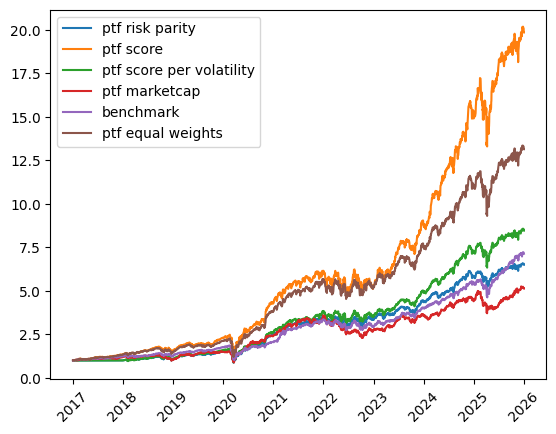

In [80]:
alpha = 0.1
portfolio  = Backtest(screen,alpha = alpha)
daily = {
            'equal': portfolio[0]
        }

for method in ['risk parity','score','score per volatility','marketcap']:
 
    daily[method] = Backtest(screen,alpha=alpha,
                             weight_method=method,
                             decay = 0.8,
                             short=False,
                             neutral=True)[0]
    
    plt.plot(daily[method].index,daily[method]['ptf'],label='ptf ' + method)

y = (1+portfolio[1].drop_duplicates(subset='Date')['benchmark']).cumprod()
plt.plot(daily['equal'].index,y,label='benchmark')
plt.plot(daily['equal'].index,daily['equal']['ptf'],label='ptf equal weights')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [48]:
metrics = ['maximum drawdown','annual return','annual volatility','sharpe']
reports = { metric : [] for metric in  metrics }
reports['weight construction'] = []

for method in ['equal','risk parity','score','score per volatility','marketcap']:
    report = metrics_report(daily[method])
    reports['weight construction'].append(method)
    for metric in metrics: 
        reports[metric].append(report[metric])

reports = pd.DataFrame(reports)
reports

,maximum drawdown,annual return,annual volatility,sharpe,weight construction
0,0.469784,0.315763,0.238296,1.325087,equal
1,0.451516,0.231574,0.213086,1.086760,risk parity
2,0.481426,0.367267,0.260448,1.410136,score
3,0.472671,0.264079,0.227054,1.163067,score per volatility
4,0.422706,0.209069,0.231035,0.904922,marketcap


In [ ]:
marko =  Backtest(screen, weight_method='markowitz', rolling=252, alpha=0.2, short=True,
                  risk_aversion = 0, markowitz_rebalance_freq=5,
                  w_max = 0.1,
                 neutral=True, decay=0.8, cost_bps=0.0, renormalize_gross=True,
             )


In [ ]:
metrics_report(marko[0])#['n_positions'].mean()